<a href="https://colab.research.google.com/github/CheilaBaiao/Pantanal/blob/main/5)Hotspot_corrigido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title HOTSPOT-1 — Setup, Drive, paths e parâmetros

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

import gc
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio as rio
import matplotlib.pyplot as plt

from rasterio.features import geometry_mask
from scipy.signal import convolve2d
from scipy.stats import hypergeom
from matplotlib.colors import ListedColormap, BoundaryNorm

# =========================================================
# PATHS
# =========================================================

ROOT = Path(
    "/content/drive/MyDrive/Pantanal_TippingPoints"
).resolve()

OUT_ROOT = (
    ROOT /
    "index" /
    "outputs"
)

# IMPORTANTE: TTR CORRIGIDO
REC_DIR = (
    OUT_ROOT /
    "recovery_nb3_corrected"
)

HOT_DIR = (
    OUT_ROOT /
    "hotspot_corrected"
)

RASTER_DIR = (
    HOT_DIR /
    "rasters"
)

TABLE_DIR = (
    HOT_DIR /
    "tables"
)

FIG_DIR = (
    HOT_DIR /
    "figures"
)

QC_DIR = (
    HOT_DIR /
    "qc"
)

for d in [
    HOT_DIR,
    RASTER_DIR,
    TABLE_DIR,
    FIG_DIR,
    QC_DIR
]:
    d.mkdir(
        parents=True,
        exist_ok=True
    )

# =========================================================
# ENTRADAS
# =========================================================

FIRST_FIRE_FP = (
    REC_DIR /
    "first_fire_yyyymm.tif"
)

PANTANAL_SHP = (
    ROOT /
    "Pantanal.shp"
)

STATUS_FPS = {
    "NDVI":
        REC_DIR /
        "ttr_status_NDVI.tif",

    "EVI":
        REC_DIR /
        "ttr_status_EVI.tif",

    "NBR":
        REC_DIR /
        "ttr_status_NBR.tif",

    "VOD":
        REC_DIR /
        "ttr_status_VOD.tif"
}

for fp in [
    FIRST_FIRE_FP,
    PANTANAL_SHP,
    *STATUS_FPS.values()
]:
    assert fp.exists(), (
        f"Arquivo ausente: {fp}"
    )

# =========================================================
# STATUS TTR CORRIGIDO
# =========================================================

STATUS_RECOVERED = 1
STATUS_NOT_REACHED = 2
STATUS_INSUFFICIENT = 3
STATUS_NO_IMPACT = 4

# =========================================================
# PARÂMETROS HOTSPOT
# =========================================================

R_KM = 5.0

MIN_SUPPORT = 30

FDR_ALPHA = 0.05

# último primeiro fogo que permite
# 18 bimestres completos até 2021-11
LAST_ELIGIBLE_FIRE = 201811

INDICES = [
    "NDVI",
    "EVI",
    "NBR",
    "VOD"
]

SEED = 42   # mantido apenas para rastreabilidade

print(
    "✔ REC_DIR:",
    REC_DIR
)

print(
    "✔ HOT_DIR:",
    HOT_DIR
)

print(
    "✔ Kernel:",
    R_KM,
    "km"
)

print(
    "✔ MIN_SUPPORT:",
    MIN_SUPPORT
)

print(
    "✔ FDR alpha:",
    FDR_ALPHA
)

print(
    "✔ Último fogo elegível:",
    LAST_ELIGIBLE_FIRE
)

Mounted at /content/drive
✔ REC_DIR: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/recovery_nb3_corrected
✔ HOT_DIR: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/hotspot_corrected
✔ Kernel: 5.0 km
✔ MIN_SUPPORT: 30
✔ FDR alpha: 0.05
✔ Último fogo elegível: 201811


In [ ]:
# @title HOTSPOT-2 — Reclassificação TTR corrigida + união dos índices

# =========================================================
# HELPERS
# =========================================================

def read_float(fp):

    with rio.open(fp) as ds:

        a = ds.read(
            1
        ).astype(
            "float32"
        )

        prof = ds.profile.copy()
        tf = ds.transform
        crs = ds.crs
        nd = ds.nodata

    if nd is not None:

        try:

            if np.isfinite(nd):

                a[
                    a == nd
                ] = np.nan

        except Exception:
            pass

    return (
        a,
        prof,
        tf,
        crs
    )


def write_u8(
    fp,
    arr,
    ref_profile,
    nodata=255
):

    prof = (
        ref_profile.copy()
    )

    prof.update(
        dtype="uint8",
        count=1,
        nodata=nodata,
        compress="deflate"
    )

    tmp = fp.with_name(
        "tmp_" +
        fp.name
    )

    with rio.open(
        tmp,
        "w",
        **prof
    ) as ds:

        ds.write(
            arr.astype(
                "uint8"
            ),
            1
        )

    tmp.replace(fp)


# =========================================================
# FIRST FIRE
# =========================================================

ff, ref_prof, REF_TF, REF_CRS = (
    read_float(
        FIRST_FIRE_FP
    )
)

H, W = ff.shape

# =========================================================
# PANTANAL MASK
# =========================================================

pant = gpd.read_file(
    PANTANAL_SHP
).to_crs(
    REF_CRS
)

pant_mask = geometry_mask(
    pant.geometry,
    out_shape=(
        H,
        W
    ),
    transform=REF_TF,
    invert=True
)

# =========================================================
# ELEGIBILIDADE TEMPORAL
# =========================================================

burned = (
    np.isfinite(ff)
    &
    (
        ff > 0
    )
)

eligible_fire = (
    burned
    &
    pant_mask
    &
    (
        ff <=
        LAST_ELIGIBLE_FIRE
    )
)

print(
    "✔ Pixels queimados no Pantanal:",
    f"{burned.sum():,}"
)

print(
    "✔ Fogo elegível até 2018-11:",
    f"{eligible_fire.sum():,}"
)

# =========================================================
# STATUS POR ÍNDICE
# =========================================================

problem_by_index = {}

evaluable_by_index = {}

qc_rows = []

for idx in INDICES:

    status, prof, tf, crs = (
        read_float(
            STATUS_FPS[
                idx
            ]
        )
    )

    assert (
        status.shape ==
        ff.shape
    )

    assert (
        str(crs) ==
        str(REF_CRS)
    )

    # ---------------------------------------------
    # Avaliável para recuperação:
    #
    # 1 = recovered
    # 2 = threshold not reached
    #
    # ---------------------------------------------

    evaluable = (
        eligible_fire
        &
        (
            (
                status ==
                STATUS_RECOVERED
            )
            |
            (
                status ==
                STATUS_NOT_REACHED
            )
        )
    )

    # ---------------------------------------------
    # Problema:
    #
    # SOMENTE status 2
    # ---------------------------------------------

    problem = (
        eligible_fire
        &
        (
            status ==
            STATUS_NOT_REACHED
        )
    )

    evaluable_by_index[
        idx
    ] = evaluable

    problem_by_index[
        idx
    ] = problem

    n_eval = int(
        evaluable.sum()
    )

    n_prob = int(
        problem.sum()
    )

    qc_rows.append({

        "index":
            idx,

        "n_evaluable":
            n_eval,

        "n_nonrecovered":
            n_prob,

        "nonrecovered_pct":
            (
                100.0 *
                n_prob /
                n_eval
                if n_eval
                else np.nan
            ),

        "status3_insufficient":
            int(
                (
                    eligible_fire
                    &
                    (
                        status ==
                        STATUS_INSUFFICIENT
                    )
                ).sum()
            ),

        "status4_no_detectable_impact":
            int(
                (
                    eligible_fire
                    &
                    (
                        status ==
                        STATUS_NO_IMPACT
                    )
                ).sum()
            )
    })

# =========================================================
# UNIÃO
# =========================================================

union_evaluable = np.zeros(
    (
        H,
        W
    ),
    dtype=bool
)

union_problem = np.zeros(
    (
        H,
        W
    ),
    dtype=bool
)

problem_count = np.zeros(
    (
        H,
        W
    ),
    dtype="uint8"
)

for idx in INDICES:

    union_evaluable |= (
        evaluable_by_index[
            idx
        ]
    )

    union_problem |= (
        problem_by_index[
            idx
        ]
    )

    problem_count += (
        problem_by_index[
            idx
        ].astype(
            "uint8"
        )
    )

# garante que "problema" pertença ao suporte
union_problem &= (
    union_evaluable
)

# =========================================================
# QC
# =========================================================

qc = pd.DataFrame(
    qc_rows
)

display(
    qc
)

QC_STATUS_FP = (
    QC_DIR /
    "status_by_index_qc.csv"
)

qc.to_csv(
    QC_STATUS_FP,
    index=False
)

n_union_eval = int(
    union_evaluable.sum()
)

n_union_prob = int(
    union_problem.sum()
)

print(
    "\n=== UNIÃO ==="
)

print(
    "Pixels recovery-evaluable:",
    f"{n_union_eval:,}"
)

print(
    "Non-recovered em ≥1 índice:",
    f"{n_union_prob:,}"
)

print(
    "Percentual:",
    f"{100*n_union_prob/max(n_union_eval,1):.3f}%"
)

# =========================================================
# SALVAR RASTERS
#
# 0 = não
# 1 = sim
# 255 = fora do suporte
# =========================================================

eval_u8 = np.full(
    (
        H,
        W
    ),
    255,
    dtype="uint8"
)

eval_u8[
    union_evaluable
] = 1

problem_u8 = np.full(
    (
        H,
        W
    ),
    255,
    dtype="uint8"
)

problem_u8[
    union_evaluable
] = 0

problem_u8[
    union_problem
] = 1

count_u8 = np.full(
    (
        H,
        W
    ),
    255,
    dtype="uint8"
)

count_u8[
    union_evaluable
] = problem_count[
    union_evaluable
]

EVAL_FP = (
    RASTER_DIR /
    "recovery_evaluable_union_u8.tif"
)

PROBLEM_FP = (
    RASTER_DIR /
    "nonrecovered_union_anyIndex_u8.tif"
)

COUNT_FP = (
    RASTER_DIR /
    "nonrecovered_count_0to4_u8.tif"
)

write_u8(
    EVAL_FP,
    eval_u8,
    ref_prof
)

write_u8(
    PROBLEM_FP,
    problem_u8,
    ref_prof
)

write_u8(
    COUNT_FP,
    count_u8,
    ref_prof
)

print(
    "\n✔ Evaluable:",
    EVAL_FP
)

print(
    "✔ Union problem:",
    PROBLEM_FP
)

print(
    "✔ Count:",
    COUNT_FP
)

✔ Pixels queimados no Pantanal: 949,064
✔ Fogo elegível até 2018-11: 813,055


,index,n_evaluable,n_nonrecovered,nonrecovered_pct,status3_insufficient,status4_no_detectable_impact
0,NDVI,658485,2618,0.397579,571,101847
1,EVI,620686,3350,0.539725,566,139651
2,NBR,711094,5749,0.808473,569,49237
3,VOD,512829,140,0.027300,0,244516



=== UNIÃO ===
Pixels recovery-evaluable: 754,626
Non-recovered em ≥1 índice: 10,139
Percentual: 1.344%

✔ Evaluable: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/hotspot_corrected/rasters/recovery_evaluable_union_u8.tif
✔ Union problem: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/hotspot_corrected/rasters/nonrecovered_union_anyIndex_u8.tif
✔ Count: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/hotspot_corrected/rasters/nonrecovered_count_0to4_u8.tif


In [ ]:
# @title HOTSPOT-3 — Fração local + teste hipergeométrico exato + BH-FDR

# =========================================================
# HELPERS
# =========================================================

def disk_kernel(
    radius_px
):

    r = int(
        max(
            1,
            round(
                radius_px
            )
        )
    )

    y, x = np.ogrid[
        -r:r+1,
        -r:r+1
    ]

    return (
        (
            x*x +
            y*y
        )
        <=
        r*r
    ).astype(
        "float32"
    )


def fdr_bh(
    pvals,
    alpha=0.05
):

    p = np.asarray(
        pvals,
        dtype="float64"
    )

    sig = np.zeros(
        p.shape,
        dtype=bool
    )

    valid = np.isfinite(
        p
    )

    pv = p[
        valid
    ]

    if pv.size == 0:

        return (
            sig,
            np.nan
        )

    order = np.argsort(
        pv
    )

    ps = pv[
        order
    ]

    m = len(
        ps
    )

    thresholds = (
        alpha *
        np.arange(
            1,
            m + 1
        )
        /
        m
    )

    passed = np.where(
        ps <=
        thresholds
    )[0]

    if passed.size == 0:

        return (
            sig,
            np.nan
        )

    k = passed.max()

    cutoff = float(
        ps[
            k
        ]
    )

    sig[
        valid
    ] = (
        pv <=
        cutoff
    )

    return (
        sig,
        cutoff
    )


def write_f32(
    fp,
    arr,
    ref_profile
):

    prof = (
        ref_profile.copy()
    )

    prof.update(
        dtype="float32",
        count=1,
        nodata=np.nan,
        compress="deflate"
    )

    tmp = fp.with_name(
        "tmp_" +
        fp.name
    )

    with rio.open(
        tmp,
        "w",
        **prof
    ) as ds:

        ds.write(
            arr.astype(
                "float32"
            ),
            1
        )

    tmp.replace(fp)


# =========================================================
# KERNEL
# =========================================================

PIX_M = abs(
    float(
        REF_TF.a
    )
)

RADIUS_PX = (
    R_KM *
    1000.0 /
    PIX_M
)

K = disk_kernel(
    RADIUS_PX
)

print(
    "✔ Pixel:",
    f"{PIX_M:.1f} m"
)

print(
    "✔ Raio:",
    f"{RADIUS_PX:.2f} px"
)

print(
    "✔ Pixels no disco:",
    int(
        K.sum()
    )
)

# =========================================================
# CONTAGENS LOCAIS
# =========================================================

eligible_f = (
    union_evaluable.astype(
        "float32"
    )
)

problem_f = (
    union_problem.astype(
        "float32"
    )
)

local_n = convolve2d(
    eligible_f,
    K,
    mode="same",
    boundary="fill",
    fillvalue=0
)

local_k = convolve2d(
    problem_f,
    K,
    mode="same",
    boundary="fill",
    fillvalue=0
)

# arredondar porque são contagens
local_n = np.rint(
    local_n
).astype(
    "int32"
)

local_k = np.rint(
    local_k
).astype(
    "int32"
)

# =========================================================
# SUPORTE
#
# Centro precisa ser recovery-evaluable
# e vizinhança ter >=30 elegíveis.
# =========================================================

valid = (
    union_evaluable
    &
    (
        local_n >=
        MIN_SUPPORT
    )
)

frac = np.full(
    (
        H,
        W
    ),
    np.nan,
    dtype="float32"
)

frac[
    valid
] = (
    local_k[
        valid
    ]
    /
    local_n[
        valid
    ]
)

print(
    "\n✔ Centros testáveis:",
    f"{valid.sum():,}"
)

# =========================================================
# TESTE HIPERGEOMÉTRICO EXATO
#
# Universo global:
#
# N = recovery-evaluable
# M = non-recovered
#
# Para cada janela:
# n = elegíveis locais
# k = non-recovered locais
#
# P(K >= k)
# =========================================================

N_GLOBAL = int(
    union_evaluable.sum()
)

M_GLOBAL = int(
    union_problem.sum()
)

print(
    "✔ N global:",
    f"{N_GLOBAL:,}"
)

print(
    "✔ M global:",
    f"{M_GLOBAL:,}"
)

print(
    "✔ Prevalência global:",
    f"{100*M_GLOBAL/N_GLOBAL:.4f}%"
)

pvals = np.full(
    (
        H,
        W
    ),
    np.nan,
    dtype="float64"
)

n_vec = local_n[
    valid
].astype(
    "int64"
)

k_vec = local_k[
    valid
].astype(
    "int64"
)

p_vec = hypergeom.sf(
    k_vec - 1,
    N_GLOBAL,
    M_GLOBAL,
    n_vec
)

pvals[
    valid
] = p_vec

# =========================================================
# BH-FDR
# =========================================================

sig_mask, p_cutoff = fdr_bh(
    pvals,
    alpha=FDR_ALPHA
)

# garante suporte correto
sig_mask &= (
    valid
)

n_sig = int(
    sig_mask.sum()
)

print(
    "\n=== SIGNIFICÂNCIA ==="
)

print(
    "BH cutoff:",
    p_cutoff
)

print(
    "Hotspot centers:",
    f"{n_sig:,}"
)

print(
    "Percentual dos centros testáveis:",
    f"{100*n_sig/max(valid.sum(),1):.3f}%"
)

# =========================================================
# RASTER SIGNIFICATIVO
# =========================================================

sig = np.full(
    (
        H,
        W
    ),
    np.nan,
    dtype="float32"
)

sig[
    valid
] = 0

sig[
    sig_mask
] = 1

# =========================================================
# SALVAR
# =========================================================

FRAC_FP = (
    RASTER_DIR /
    f"local_fraction_nonrecovered_R{int(R_KM)}km.tif"
)

P_FP = (
    RASTER_DIR /
    f"hypergeom_pvalues_R{int(R_KM)}km.tif"
)

SIG_FP = (
    RASTER_DIR /
    f"hotspots_BH_FDR_R{int(R_KM)}km.tif"
)

write_f32(
    FRAC_FP,
    frac,
    ref_prof
)

write_f32(
    P_FP,
    pvals,
    ref_prof
)

write_f32(
    SIG_FP,
    sig,
    ref_prof
)

# =========================================================
# QC
# =========================================================

qc_hot = pd.DataFrame([{

    "radius_km":
        R_KM,

    "min_support":
        MIN_SUPPORT,

    "fdr_alpha":
        FDR_ALPHA,

    "global_evaluable":
        N_GLOBAL,

    "global_nonrecovered":
        M_GLOBAL,

    "global_nonrecovered_pct":
        (
            100.0 *
            M_GLOBAL /
            N_GLOBAL
        ),

    "tested_centers":
        int(
            valid.sum()
        ),

    "bh_p_cutoff":
        p_cutoff,

    "significant_hotspot_centers":
        n_sig,

    "significant_pct_tested":
        (
            100.0 *
            n_sig /
            max(
                valid.sum(),
                1
            )
        ),

    "local_fraction_median":
        float(
            np.nanmedian(
                frac
            )
        ),

    "local_fraction_p95":
        float(
            np.nanpercentile(
                frac,
                95
            )
        ),

    "local_fraction_max":
        float(
            np.nanmax(
                frac
            )
        )
}])

QC_HOT_FP = (
    QC_DIR /
    "hotspot_qc.csv"
)

qc_hot.to_csv(
    QC_HOT_FP,
    index=False
)

display(
    qc_hot
)

print(
    "\n✔ Fraction:",
    FRAC_FP
)

print(
    "✔ p-values:",
    P_FP
)

print(
    "✔ Hotspots:",
    SIG_FP
)

print(
    "✔ QC:",
    QC_HOT_FP
)

✔ Pixel: 300.0 m
✔ Raio: 16.67 px
✔ Pixels no disco: 901

✔ Centros testáveis: 753,425
✔ N global: 754,626
✔ M global: 10,139
✔ Prevalência global: 1.3436%

=== SIGNIFICÂNCIA ===
BH cutoff: 0.00717058672211084
Hotspot centers: 108,062
Percentual dos centros testáveis: 14.343%


,radius_km,min_support,fdr_alpha,global_evaluable,global_nonrecovered,global_nonrecovered_pct,tested_centers,bh_p_cutoff,significant_hotspot_centers,significant_pct_tested,local_fraction_median,local_fraction_p95,local_fraction_max
0,5.0,30,0.05,754626,10139,1.343579,753425,0.007171,108062,14.342768,0.004724,0.057554,0.506667



✔ Fraction: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/hotspot_corrected/rasters/local_fraction_nonrecovered_R5km.tif
✔ p-values: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/hotspot_corrected/rasters/hypergeom_pvalues_R5km.tif
✔ Hotspots: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/hotspot_corrected/rasters/hotspots_BH_FDR_R5km.tif
✔ QC: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/hotspot_corrected/qc/hotspot_qc.csv


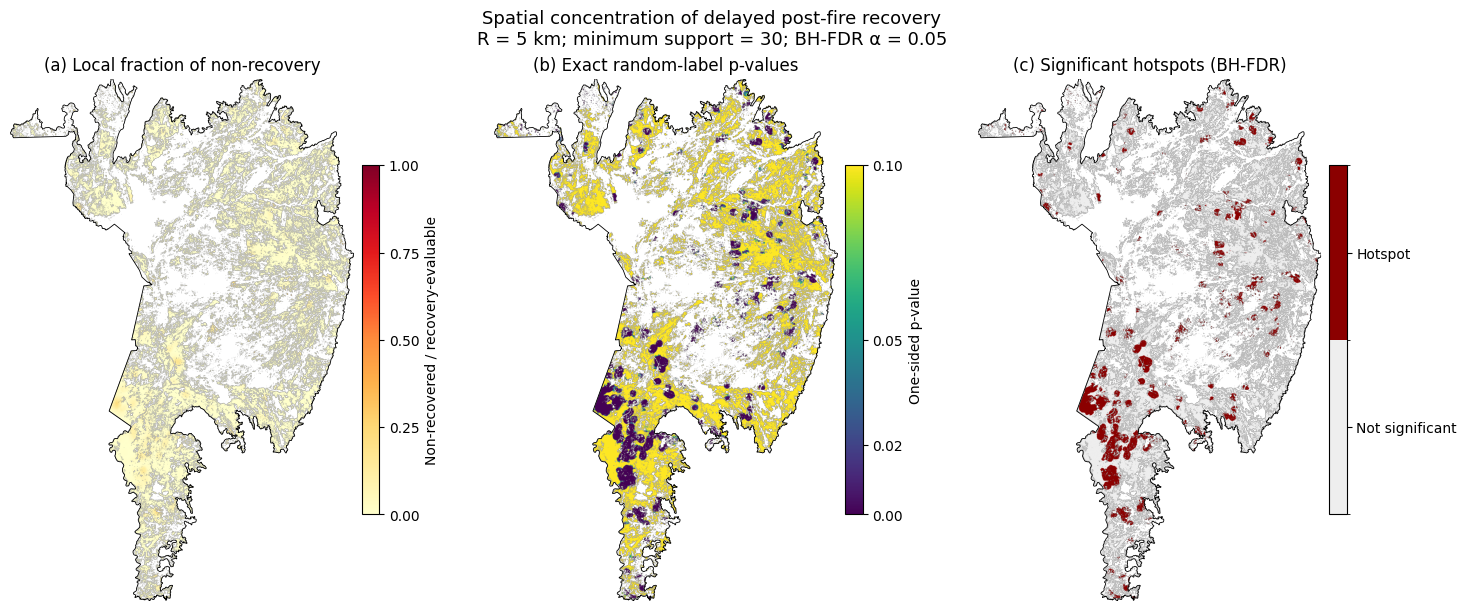

✔ Figura: /content/drive/MyDrive/Pantanal_TippingPoints/index/outputs/hotspot_corrected/figures/hotspot_panel_R5km_corrected.png


In [ ]:
# @title HOTSPOT-4 — Painel final: fração local, p-valor e hotspots FDR

# =========================================================
# EXTENT
# =========================================================

xmin = REF_TF.c
ymax = REF_TF.f

xmax = (
    xmin +
    REF_TF.a *
    W
)

ymin = (
    ymax +
    REF_TF.e *
    H
)

extent = [
    xmin,
    xmax,
    ymin,
    ymax
]

# =========================================================
# FIGURA
# =========================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(
        15,
        6
    ),
    constrained_layout=True
)

# =========================================================
# (a) FRAÇÃO LOCAL
# =========================================================

im0 = axes[0].imshow(
    frac,
    extent=extent,
    origin="upper",
    cmap="YlOrRd",
    vmin=0,
    vmax=1
)

pant.boundary.plot(
    ax=axes[0],
    color="black",
    linewidth=0.6
)

axes[0].set_title(
    "(a) Local fraction of non-recovery"
)

axes[0].axis(
    "off"
)

c0 = fig.colorbar(
    im0,
    ax=axes[0],
    fraction=0.045,
    pad=0.02
)

c0.set_label(
    "Non-recovered / recovery-evaluable"
)

c0.set_ticks(
    [
        0,
        0.25,
        0.50,
        0.75,
        1.00
    ]
)

# =========================================================
# (b) P-VALUES
# =========================================================

P_show = pvals.copy()

p_vmax = 0.10

im1 = axes[1].imshow(
    P_show,
    extent=extent,
    origin="upper",
    cmap="viridis",
    vmin=0,
    vmax=p_vmax
)

pant.boundary.plot(
    ax=axes[1],
    color="black",
    linewidth=0.6
)

axes[1].set_title(
    "(b) Exact random-label p-values"
)

axes[1].axis(
    "off"
)

c1 = fig.colorbar(
    im1,
    ax=axes[1],
    fraction=0.045,
    pad=0.02
)

c1.set_label(
    "One-sided p-value"
)

c1.set_ticks(
    [
        0.00,
        0.02,
        0.05,
        0.10
    ]
)

# =========================================================
# (c) HOTSPOTS
# =========================================================

sig_show = np.ma.masked_invalid(
    sig
)

cmap_sig = ListedColormap(
    [
        "#eeeeee",
        "#8b0000"
    ]
)

norm_sig = BoundaryNorm(
    [
        -0.5,
        0.5,
        1.5
    ],
    cmap_sig.N
)

im2 = axes[2].imshow(
    sig_show,
    extent=extent,
    origin="upper",
    cmap=cmap_sig,
    norm=norm_sig
)

pant.boundary.plot(
    ax=axes[2],
    color="black",
    linewidth=0.6
)

axes[2].set_title(
    "(c) Significant hotspots (BH-FDR)"
)

axes[2].axis(
    "off"
)

c2 = fig.colorbar(
    im2,
    ax=axes[2],
    ticks=[
        0,
        1
    ],
    fraction=0.045,
    pad=0.02
)

c2.ax.set_yticklabels(
    [
        "Not significant",
        "Hotspot"
    ]
)

# =========================================================
# TÍTULO
# =========================================================

fig.suptitle(
    (
        "Spatial concentration of delayed post-fire recovery\n"
        f"R = {R_KM:g} km; minimum support = {MIN_SUPPORT}; "
        f"BH-FDR α = {FDR_ALPHA:.2f}"
    ),
    fontsize=13
)

# =========================================================
# SALVAR
# =========================================================

FIG_FP = (
    FIG_DIR /
    f"hotspot_panel_R{int(R_KM)}km_corrected.png"
)

fig.savefig(
    FIG_FP,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✔ Figura:",
    FIG_FP
)